In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from joblib import Parallel, delayed
import time
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
    

from data_prep import create_artificial_dataset, load_spambase, load_sonar, load_breast_cancer_data, load_ionosphere
from missingness import MissingDataGenerator
from fista import FISTA
from unlabeled import UnlabeledLogReg

In [2]:
artificial_X, artificial_y = create_artificial_dataset()
spambase_X, spambase_y = load_spambase()
sonar_X, sonar_y = load_sonar()
breast_X, breast_y = load_breast_cancer_data()
ionosphere_X, ionosphere_y = load_ionosphere()

Artificial dataset prepared: X shape (2000, 50), y shape (2000,), dropped collinear features: 0
Loading Spambase dataset...
Spambase loaded: X shape (4601, 56), y shape (4601,), dropped collinear features: 1
Loading Sonar dataset...
Sonar loaded: X shape (208, 60), y shape (208,), dropped collinear features: 0
Loading Breast Cancer dataset...
Breast Cancer loaded: X shape (569, 23), y shape (569,), dropped collinear features: 7
Positive labels (1s): 357 out of 569
Loading Ionosphere dataset...
Ionosphere loaded: X shape (351, 34), y shape (351,), dropped collinear features: 0


# Experiments
Comparison of methods under different label-missingness mechanisms.

In [3]:
datasets = {
    "Artificial": (artificial_X, artificial_y),
    "Spambase": (spambase_X, spambase_y),
    "Sonar": (sonar_X, sonar_y),
    "BreastCancer": (breast_X, breast_y),
    "Ionosphere": (ionosphere_X, ionosphere_y)
}

def evaluate_metrics(model, X_test, y_test):
    """Compute evaluation metrics on the test set."""
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Balanced_Acc": balanced_accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, probas)
    }

def run_single_scheme_experiment(dataset_name, X, y, scheme_name):
    """Run all methods for one dataset and one missingness scheme."""
    X_train, X_test, y_train_true, y_test_true = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    if scheme_name == "MCAR":
        X_train, y_train_obs = MissingDataGenerator.apply_mcar(
            X_train, y_train_true, c=0.3, random_state=42
        )
    elif scheme_name == "MAR1":
        X_train, y_train_obs = MissingDataGenerator.apply_mar1(
            X_train, y_train_true, random_state=42
        )
    elif scheme_name == "MAR2":
        X_train, y_train_obs = MissingDataGenerator.apply_mar2(
            X_train, y_train_true, random_state=42
        )
    elif scheme_name == "MNAR":
        X_train, y_train_obs = MissingDataGenerator.apply_mnar(
            X_train, y_train_true, random_state=42
        )
    else:
        raise ValueError(f"Unknown scheme: {scheme_name}")

    results = []
    base_lambda = [0.01]

    oracle = FISTA(lambdas=base_lambda).fit(X_train, y_train_true)
    res_oracle = evaluate_metrics(oracle, X_test, y_test_true)
    res_oracle.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Oracle"})
    results.append(res_oracle)

    naive_mask = y_train_obs != -1
    naive = FISTA(lambdas=base_lambda).fit(X_train[naive_mask], y_train_obs[naive_mask])
    res_naive = evaluate_metrics(naive, X_test, y_test_true)
    res_naive.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Naive"})
    results.append(res_naive)

    pseudo = UnlabeledLogReg(model=FISTA(lambdas=base_lambda), method="pseudo_labeling")
    pseudo.fit(X_train, y_train_obs)
    res_pseudo = evaluate_metrics(pseudo, X_test, y_test_true)
    res_pseudo.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Pseudo-Labeling"})
    results.append(res_pseudo)

    em = UnlabeledLogReg(model=FISTA(lambdas=base_lambda), method="em")
    em.fit(X_train, y_train_obs)
    res_em = evaluate_metrics(em, X_test, y_test_true)
    res_em.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Soft-EM"})
    results.append(res_em)

    return results

In [4]:
print("Experiment 1: schemes comparison")
start_time = time.time()

schemes = ["MCAR", "MAR1", "MAR2", "MNAR"]
tasks = []
for data_name, (X, y) in datasets.items():
    for scheme in schemes:
        tasks.append((data_name, X, y, scheme))

all_results = Parallel(n_jobs=-1)(
    delayed(run_single_scheme_experiment)(d_name, X, y, sch)
    for d_name, X, y, sch in tasks
)

flat_results = [item for sublist in all_results for item in sublist]
df_experiment1 = pd.DataFrame(flat_results)
df_experiment1 = df_experiment1[["Dataset", "Scheme", "Model", "Accuracy", "Balanced_Acc", "F1", "ROC_AUC"]]

elapsed = time.time() - start_time
print(f"Experiment 1 completed in {elapsed:.2f} seconds")
display(df_experiment1.groupby(["Dataset", "Scheme", "Model"]).mean().round(4))

Experiment 1: schemes comparison
Experiment 1 completed in 178.10 seconds


Accuracy  Balanced_Acc      F1  ROC_AUC
Dataset    Scheme Model                                                   
Artificial MAR1   Naive              0.8575        0.8573  0.8535   0.9286
                  Oracle             0.8700        0.8700  0.8680   0.9428
                  Pseudo-Labeling    0.8575        0.8575  0.8550   0.9274
                  Soft-EM            0.8550        0.8549  0.8520   0.9282
           MAR2   Naive              0.8625        0.8627  0.8615   0.9320
...                                     ...           ...     ...      ...
Spambase   MCAR   Soft-EM            0.8740        0.8799  0.8606   0.9385
           MNAR   Naive              0.8730        0.8711  0.8513   0.9208
                  Oracle             0.7785        0.8072  0.7918   0.8874
                  Pseudo-Labeling    0.8165        0.8184  0.7931   0.8367
                  Soft-EM            0.7600        0.7368  0.6736   0.7520

[80 rows x 4 columns]

Experiment 2: impact of c in MCAR


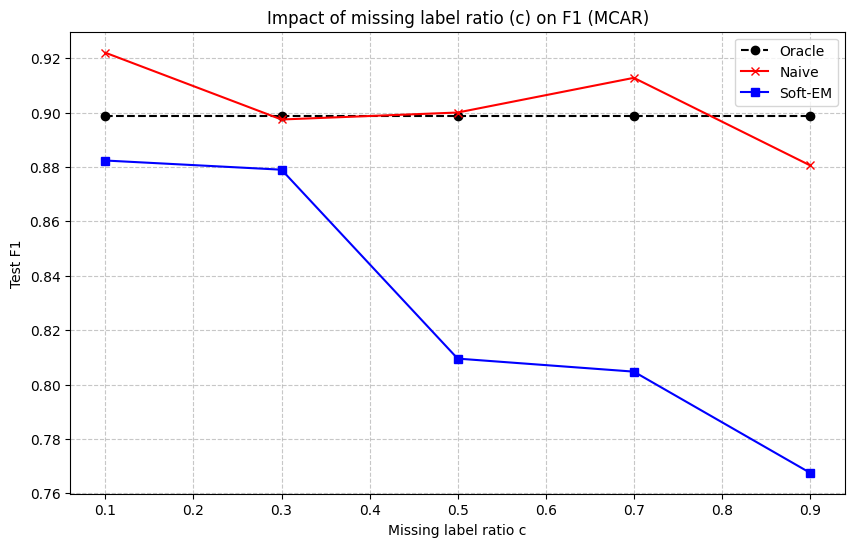

In [5]:
print("Experiment 2: impact of c in MCAR")

c_values = [0.1, 0.3, 0.5, 0.7, 0.9]
X_bc, y_bc = datasets["BreastCancer"]
X_train, X_test, y_train_true, y_test_true = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

c_results = []
for c in c_values:
    _, y_train_obs = MissingDataGenerator.apply_mcar(
        X_train, y_train_true, c=c, random_state=42
    )

    oracle = FISTA(lambdas=[0.01]).fit(X_train, y_train_true)

    naive_mask = y_train_obs != -1
    naive = FISTA(lambdas=[0.01]).fit(X_train[naive_mask], y_train_obs[naive_mask])

    em = UnlabeledLogReg(model=FISTA(lambdas=[0.01]), method="em").fit(X_train, y_train_obs)

    c_results.append({
        "c_value": c,
        "Oracle": f1_score(y_test_true, oracle.predict(X_test)),
        "Naive": f1_score(y_test_true, naive.predict(X_test)),
        "Soft-EM": f1_score(y_test_true, em.predict(X_test))
    })

df_c = pd.DataFrame(c_results).set_index("c_value")

plt.figure(figsize=(10, 6))
plt.plot(df_c.index, df_c["Oracle"], marker="o", linestyle="--", color="black", label="Oracle")
plt.plot(df_c.index, df_c["Naive"], marker="x", color="red", label="Naive")
plt.plot(df_c.index, df_c["Soft-EM"], marker="s", color="blue", label="Soft-EM")
plt.title("Impact of missing label ratio (c) on F1 (MCAR)")
plt.xlabel("Missing label ratio c")
plt.ylabel("Test F1")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Task 2: lambda validation and coefficient paths
Fitting FISTA on lambda grid
Best lambda: 0.0001


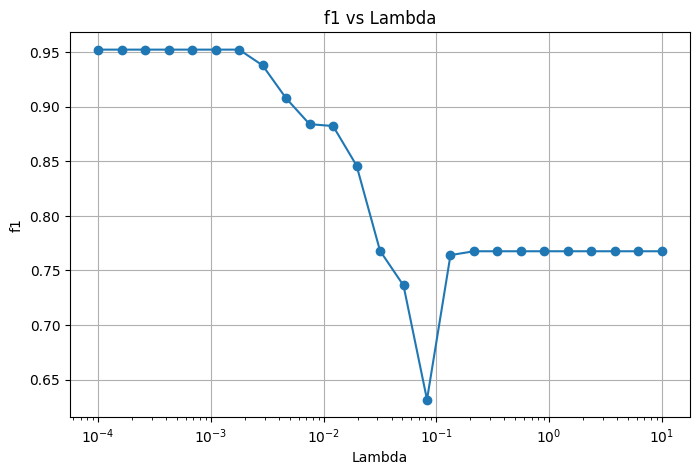

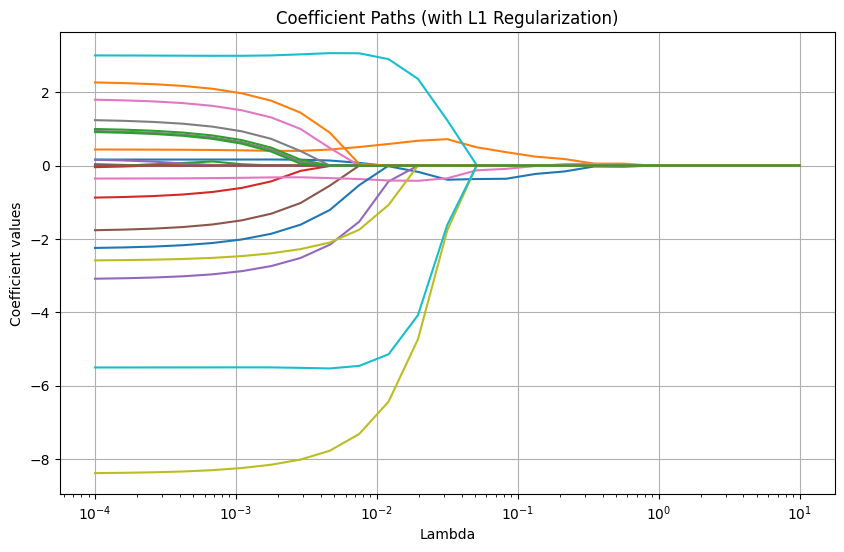

In [6]:
print("Task 2: lambda validation and coefficient paths")

X_bc, y_bc = datasets["BreastCancer"]
X_train, X_val, y_train, y_val = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

lambda_grid = np.logspace(-4, 1, 25)
fista_tuner = FISTA(lambdas=lambda_grid, max_iter=500)

print("Fitting FISTA on lambda grid")
fista_tuner.fit(X_train, y_train)

best_lambda = fista_tuner.validate(X_val, y_val, measure="f1")
print(f"Best lambda: {best_lambda:.4f}")

fista_tuner.plot(measure="f1")
fista_tuner.plot_coefficients()

# Sklearn comparison
Comparison of FISTA with sklearn LogisticRegression (L1).

In [7]:
from sklearn.linear_model import LogisticRegression

print("Sklearn L1 comparison")
start = time.time()
sk_model = LogisticRegression(penalty="l1", solver="liblinear", C=1 / 0.01)
sk_model.fit(X_train, y_train_true)
sk_time = time.time() - start

sk_preds = sk_model.predict(X_test)
print(f"Sklearn time: {sk_time:.4f} s")
print(f"Sklearn F1: {f1_score(y_test_true, sk_preds):.4f}")

Sklearn L1 comparison
Sklearn time: 0.1008 s
Sklearn F1: 0.9787


C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


# Running on new data

In [8]:
def run_on_custom_data(csv_path, target_column):
    """Load CSV, preprocess features, and train UnlabeledLogReg."""
    print(f"Loading data from {csv_path}")
    df = pd.read_csv(csv_path)

    X_new = df.drop(columns=[target_column]).values
    y_new = df[target_column].values

    X_new = SimpleImputer(strategy="mean").fit_transform(X_new)
    X_new = StandardScaler().fit_transform(X_new)

    model = UnlabeledLogReg(model=FISTA(lambdas=[0.01]), method="em")
    model.fit(X_new, y_new)
    print("Model trained")
    return model